<a href="https://colab.research.google.com/github/Craignewkirk/geog761/blob/main/GEOG761_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee

In [ ]:
ee.Authenticate()

In [ ]:
ee.Initialize(project='geog-761-503623')

In [ ]:
# Print the elevation of Mount Everest.

In [ ]:
dem = ee.Image('USGS/SRTMGL1_003')
xy = ee.Geometry.Point([86.9250, 27.9881])
elev = dem.sample(xy, 30).first().get('elevation').getInfo()
print('Mount Everest elevation (m):', elev)

Mount Everest elevation (m): 8729


In [13]:
!git clone https://github.com/tpfd/SatelliteDataAI-UOA.git

Cloning into 'SatelliteDataAI-UOA'...
remote: Enumerating objects: 143, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 143 (delta 77), reused 37 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (143/143), 1.13 MiB | 6.15 MiB/s, done.
Resolving deltas: 100% (77/77), done.


#Lecture 2 - Exercise 1

In [62]:

# Import the Scikit-Learn lib (SKLearn), it is built in to Colab already so no need to pip install.
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

In [63]:
#Create synthetic dataset
X, y = make_classification(
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_samples=500,
    random_state=10
)

In [64]:
# Train a single decision tree
tree = DecisionTreeClassifier(max_depth=3).fit(X, y)

In [65]:
# Train a random forest
forest = RandomForestClassifier(n_estimators=100, max_depth=3).fit(X, y)

Text(0.5, 1.0, 'Random Forest')

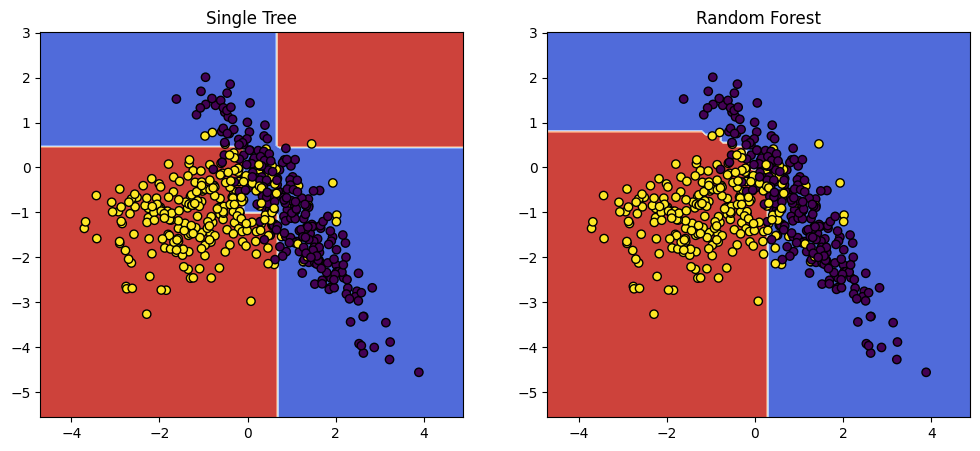

In [66]:
#Plot decision boundaries
_, ax = plt.subplots(1, 2, figsize=(12, 5))
DecisionBoundaryDisplay.from_estimator(
    tree,
    X,
    response_method='predict',
    ax=ax[0],
    cmap="coolwarm"
)
ax[0].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
ax[0].set_title("Single Tree")

DecisionBoundaryDisplay.from_estimator(
    forest,
    X,
    response_method='predict',
    ax=ax[1],
    cmap="coolwarm"
)
ax[1].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
ax[1].set_title("Random Forest")

Questions

Pair up and answer the following questions together:

How 'good' is the intial classification?
It classifies the easy stuff - data points that have space between a data point of another classification - easy enough, however there's overlap once the data points start getting closer together.

What are the fail states?
n_features != 2

What is the optimum setting for both approaches?
n_features must equal 2.
max_depth too low has the model underfitting, too high has it overfitting.  3-5 seems to be a sweet spot.
for n_estimators,

#Lecture 2 - Exercise 2

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_wine, load_iris, load_diabetes, load_digits, load_linnerud, load_breast_cancer

# Load real data
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

tree = DecisionTreeClassifier().fit(X_train, y_train)
forest = RandomForestClassifier(
    n_estimators=100
).fit(X_train, y_train)

print("Tree accuracy:", accuracy_score(y_test, tree.predict(X_test)))
print("Forest accuracy:", accuracy_score(y_test, forest.predict(X_test)))

Tree accuracy: 0.8703703703703703
Forest accuracy: 0.9629629629629629


load_diabetes = low accuracy. 0-2%.
load_digits = 85-100% accuracy
load_iris = high accuracy, often the same accuracy numbers for trees and forests.
load_breast_cancer = high accuracy. 85-100%, often in 90s.

What is the average performance gain (accuracy) differential between the tree and the forest for the wine and iris datasets?  
